In [1]:
# On some systems the linear algebra system BLAS tries to use multiple
# threads and ends up slowing the calculations down. Here we force it
# to not use threads.
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../..")
from pypanodecoder import eventbuilder
from pypanodecoder import pedestals
from pypanodecoder import plotting
from pypanodecoder import pointing
from pypanodecoder import stars
from pypanodecoder import dqm

In [8]:
mod = 252 # Fern

datadir = "/data/CTA02/fegan/PANOSETI/data/L0/"
images_E = eventbuilder.load_pff_camera_images(datadir + f'20260716/pff/obs_Palomar.start_2026-07-16T08:09:13Z.runtype_obs-test.pffd/**/*dp_ph1024.bpp_2.module_{mod}*.pff')
images_W = eventbuilder.load_pff_camera_images(datadir + f'20260716/pff/obs_Palomar.start_2026-07-16T08:35:22Z.runtype_obs-test.pffd/**/*dp_ph1024.bpp_2.module_{mod}*.pff')

print(images_E)
print(images_W)

<CameraImages events=18629 gtis=[0]>
<CameraImages events=55304 gtis=[0]>


In [12]:
tknot_E, pedspline_E, pedsigma_E = pedestals.calculate_spline_location_and_scale(images_E, loud=True)
tknot_W, pedspline_W, pedsigma_W = pedestals.calculate_spline_location_and_scale(images_W, loud=True)

2026-07-16 10:10:04   3*646s : ################################ (Converged: 1024, Time: 11.72s)
2026-07-16 10:36:12  15*630s : ################################ (Converged: 1024, Time: 39.38s)


Text(0, 0.5, 'Pedestal baseline offset')

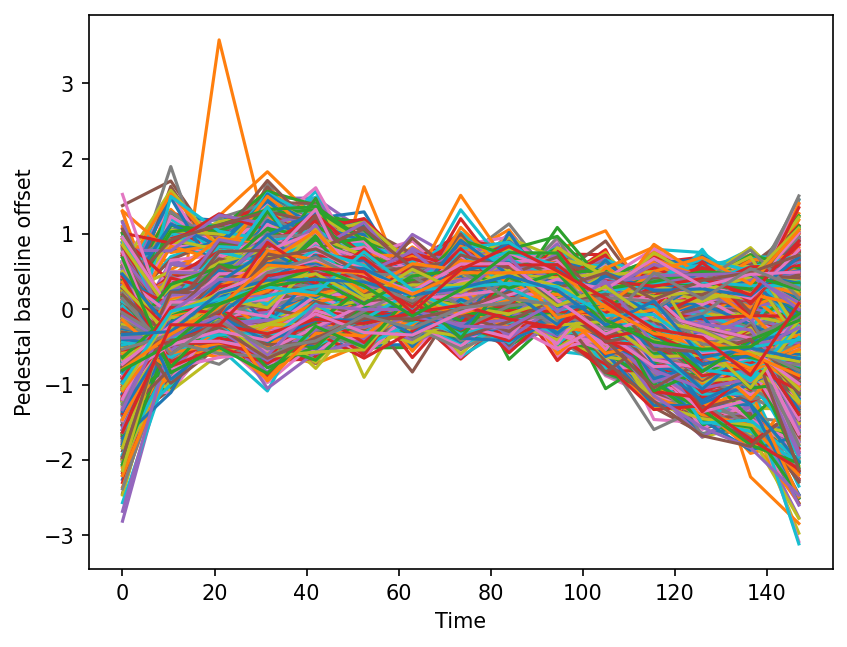

In [16]:
plt.figure(dpi=150)
plt.plot(tknot_W/1e9/60, (pedspline_W - np.mean(pedspline_W,axis=-1)[:,:,None]).reshape(1024,-1).transpose());
plt.xlabel('Time')
plt.ylabel('Pedestal baseline offset')

Text(0, 0.5, 'Pedestal baseline offset')

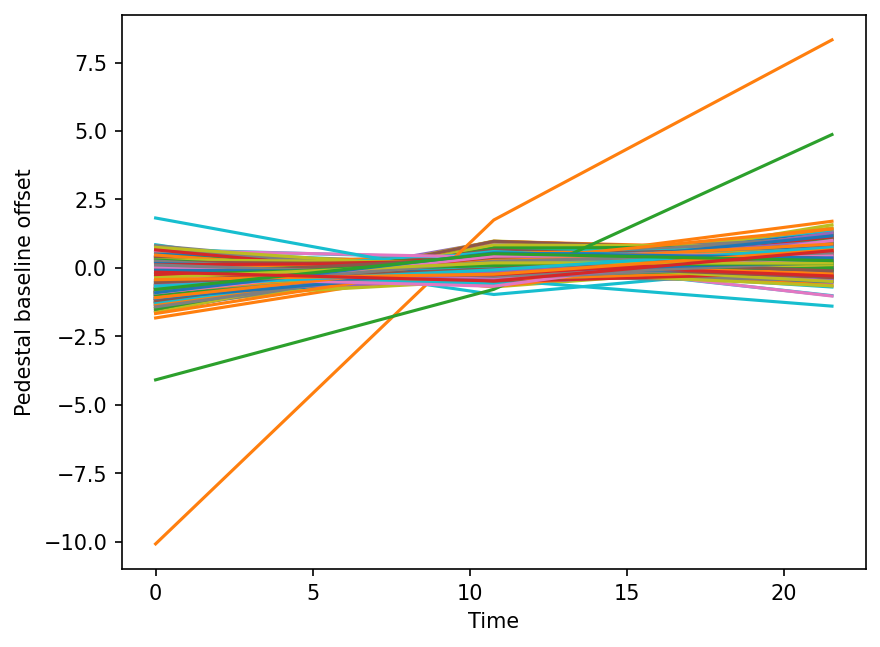

In [17]:
plt.figure(dpi=150)
plt.plot(tknot_E/1e9/60, (pedspline_E - np.mean(pedspline_E,axis=-1)[:,:,None]).reshape(1024,-1).transpose());
plt.xlabel('Time')
plt.ylabel('Pedestal baseline offset')

In [ ]:
coords = pointing.get_target_coordinates('mgroj2019+37')
starlist = stars.get_bright_stars(*coords, max_magnitude=5.5)

In [20]:
relvar = (pedsigma_E**2-pedsigma_W**2)/np.minimum(pedsigma_E**2,pedsigma_W**2)

Idx   HR Name           RA [deg]  Dec [deg]   Vmag    B-V  Sep [deg]    X [pix]    Y [pix]
------------------------------------------------------------------------------------------
0   7796 37Gam Cyg      305.5571    40.2567   2.20   0.68     3.4833      -2.25      11.02
1   7949 53Eps Cyg      311.5529    33.9703   2.46   1.03     6.3195     -18.55      -8.66
2   7615 21Eta Cyg      299.0767    35.0833   3.89   1.02     4.8394      14.73      -5.28
3   7834 41 Cyg         307.3487    30.3686   4.01   0.40     6.8574      -7.57     -20.90
4   7564 Chi Cyg        297.6412    32.9142   4.23   1.82     6.9600      19.06     -12.07
5   7806 39 Cyg         305.9654    32.1900   4.43   1.33     4.7820      -3.61     -15.03
6   7963 54Lam Cyg      311.8521    36.4908   4.53  -0.11     5.7896     -18.73      -0.45
7   7866 47 Cyg         308.4758    35.2508   4.61   1.60     3.4833     -10.10      -4.96
8   7763 34 Cyg         304.4467    38.0331   4.81   0.42     1.1966       0.51       3.83

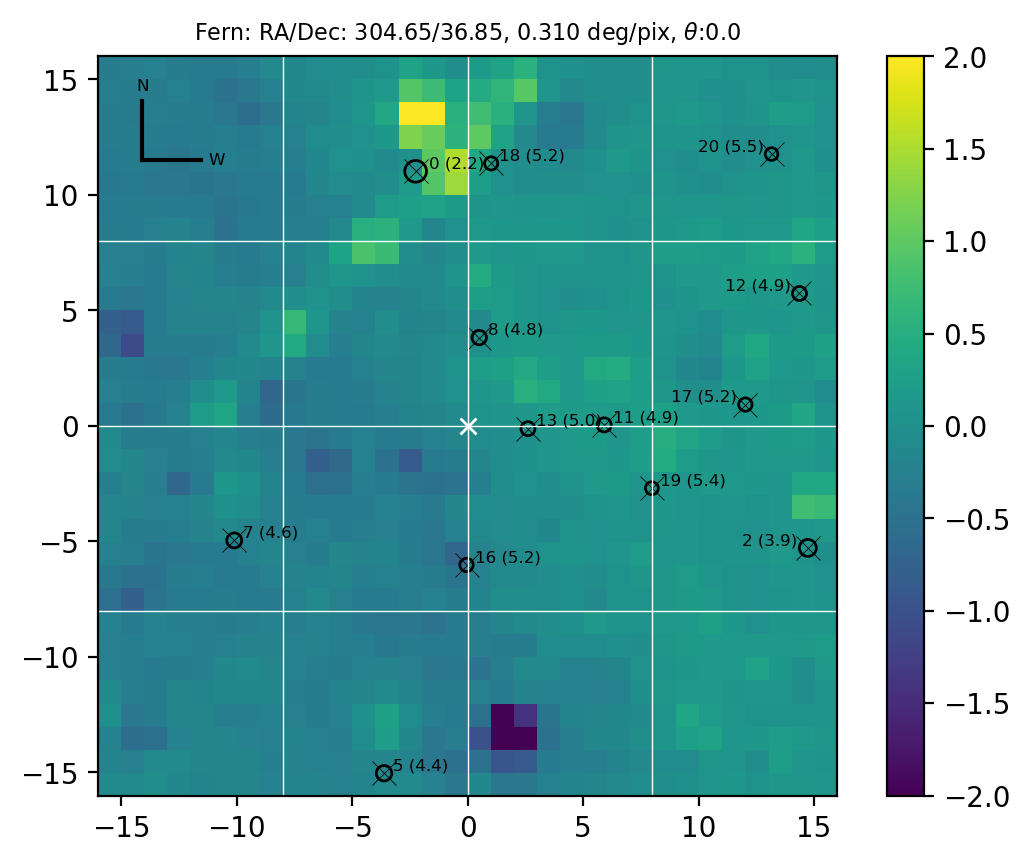

In [32]:
fig = plt.figure(dpi=200)
fig, ax, ps = plotting.plot_image(relvar, fig=fig, plate_scale=1.0)

ps.set_clim(-2,2)

pnt = pointing.PointingSolution(*coords, plate_scale=0.31, theta=0)
pnt.print_stars(starlist)

plotting.overlay_stars(starlist, ax=ax, ps=pnt, clip_to_axes=True, show_mags=True, auto_align=True, use_index=True, color='k', show_cross=True, loc=2, fontsize=6)
ax.plot(*pnt.sky_to_image(*coords),'xw')
ax.set_title(f'Fern: RA/Dec: {pnt.ra0:.2f}/{pnt.dec0:.2f}, {pnt.plate_scale:.3f} deg/pix, $\\theta$:{np.rad2deg(pnt.theta):.1f}', fontsize=8);


In [34]:
psfpack = np.load('/data/CTA03/fegan/PANOSETI/psf_model_pack.npz')

In [39]:
filtered_var = (psfpack['psf'] * relvar).sum(axis=(-2, -1))

(np.float64(-16.0625),
 np.float64(16.0625),
 np.float64(-16.0625),
 np.float64(16.0625))

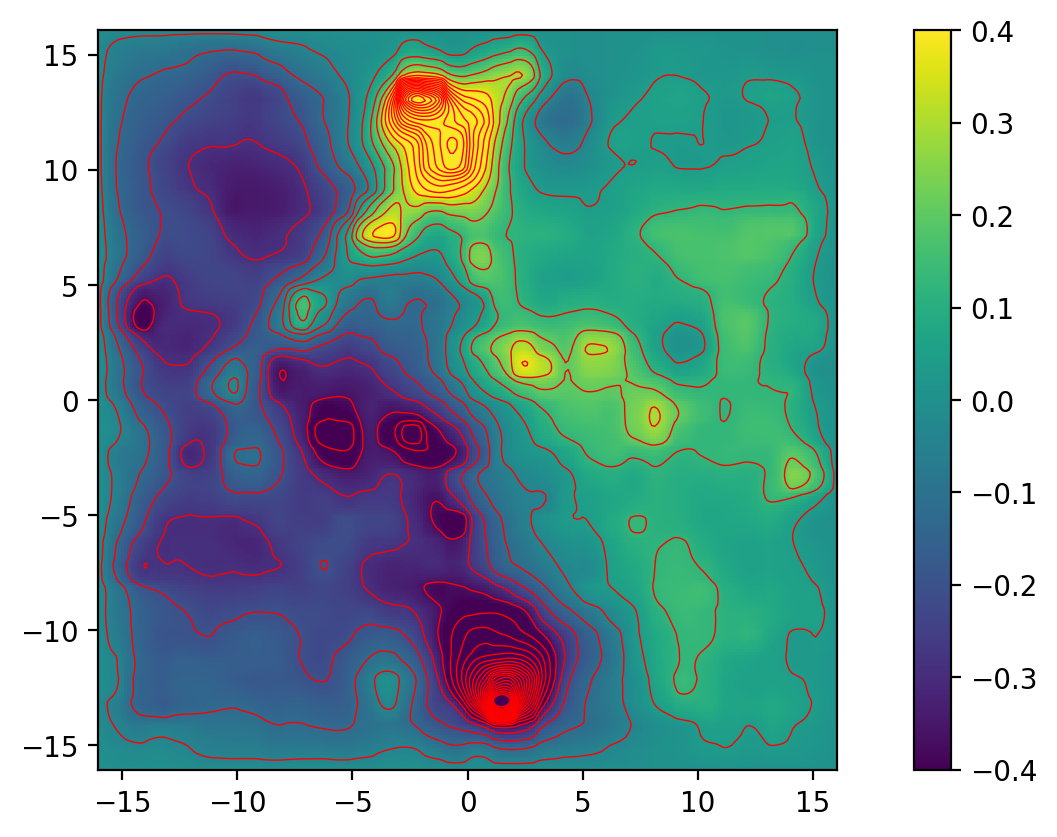

In [49]:
fig = plt.figure(dpi=200)
plt.pcolormesh(psfpack['xprincipal'], psfpack['yprincipal'], filtered_var)
plt.colorbar()
plt.clim([-0.4,0.4])
plt.contour(psfpack['xprincipal'], psfpack['yprincipal'], filtered_var, levels=np.linspace(-2,2,50), colors='r', linewidths=0.5, linestyles='-')
plt.axis('square')